In [61]:
import pandas as pd
import numpy as np

def load_orlando_timeseries(filepath):
    """
    Load Orlando 2008 real yeast time series:
    - Each row: a gene
    - Each column: a timepoint (column names are numeric)
    
    Returns:
    - time: (T,) array of floats (from column headers)
    - gene_expr: (T, G) array of expression values
    - gene_names: list of G gene IDs
    """
    df = pd.read_csv(filepath, sep="\t")
    
    gene_names = df["gene_ID"].tolist()             # gene IDs
    df = df.drop(columns=["gene_ID"])               # strip gene_ID column

    time = df.columns.astype(float).values          # timepoints from header
    gene_expr = df.values.T                         # shape: (T, G)

    print(f"✔ Loaded file: {filepath}")
    print(f"Time shape: {time.shape} — sample: {time[:5]}")
    print(f"Gene expression shape: {gene_expr.shape}")
    print(f"First 5 gene names: {gene_names[:5]}")

    return time, gene_expr, gene_names


# --- Usage ---
time, X, gene_names = load_orlando_timeseries(
    "../yeast_data/yeast_data/time_series/orlando2008_WildType_r1_trunc.tsv"
)


✔ Loaded file: ../yeast_data/yeast_data/time_series/orlando2008_WildType_r1_trunc.tsv
Time shape: (14,) — sample: [ 46.  62.  78.  94. 110.]
Gene expression shape: (14, 7704)
First 5 gene names: ['FOX2', 'SPCC18.05c', 'YDL157C', 'PCL6', 'PKP2']


In [62]:
# --------------------------------------------
# Step 2: Normalize and select sparse sensors
# --------------------------------------------
from sklearn.preprocessing import StandardScaler

# Normalize gene expression (each gene = one column)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)  # shape: (14, 7704)

# Select sparse sensors (choose 3 genes)
sensor_indices = [100, 300, 500, 700, 1000, 3100]  # use any valid indices < 7704
X_sparse = X_norm[:, sensor_indices]
time_ds = time  # keep full time vector
dt = time[1] - time[0]  # actual experimental spacing

In [63]:
# --------------------------------------------
# Step 3: Fit SINDy model with polynomial library
# --------------------------------------------
import pysindy as ps

model = ps.SINDy(
    optimizer=ps.STLSQ(threshold=0.001),
    feature_library=ps.PolynomialLibrary(degree=3),
    differentiation_method=ps.FiniteDifference()
)

model.fit(X_sparse, t=dt)
model.print()

(x0)' = -0.003 1 + 0.007 x0 + 0.002 x2 + 0.004 x3 + 0.007 x4 + 0.002 x0^2 + -0.004 x0 x1 + 0.006 x0 x2 + 0.003 x0 x3 + 0.009 x0 x4 + 0.012 x0 x5 + 0.004 x1^2 + -0.005 x1 x2 + -0.003 x1 x3 + -0.010 x1 x4 + -0.009 x1 x5 + 0.005 x2^2 + 0.003 x2 x3 + 0.002 x2 x4 + 0.003 x2 x5 + 0.003 x3^2 + 0.006 x3 x4 + -0.004 x3 x5 + -0.006 x4^2 + 0.010 x4 x5 + 0.003 x5^2 + -0.001 x0^3 + 0.002 x0^2 x2 + 0.008 x0^2 x3 + 0.006 x0^2 x4 + 0.010 x0^2 x5 + -0.005 x0 x1 x2 + -0.006 x0 x1 x3 + -0.007 x0 x1 x4 + -0.009 x0 x1 x5 + 0.002 x0 x2 x3 + 0.003 x0 x2 x4 + 0.006 x0 x2 x5 + -0.001 x0 x3^2 + 0.005 x0 x3 x5 + 0.005 x0 x4^2 + 0.002 x0 x4 x5 + 0.001 x1^3 + 0.005 x1^2 x2 + 0.005 x1^2 x3 + 0.008 x1^2 x4 + 0.006 x1^2 x5 + -0.007 x1 x2 x5 + -0.004 x1 x3 x4 + -0.003 x1 x3 x5 + 0.005 x1 x4^2 + -0.005 x1 x4 x5 + 0.003 x1 x5^2 + -0.007 x2^3 + -0.002 x2^2 x4 + -0.002 x2 x3^2 + -0.002 x2 x3 x5 + 0.002 x2 x4^2 + 0.001 x2 x4 x5 + 0.005 x2 x5^2 + -0.006 x3^3 + -0.005 x3^2 x4 + 0.005 x3 x4^2 + 0.004 x3 x4 x5 + 0.005 x3 x5^2 

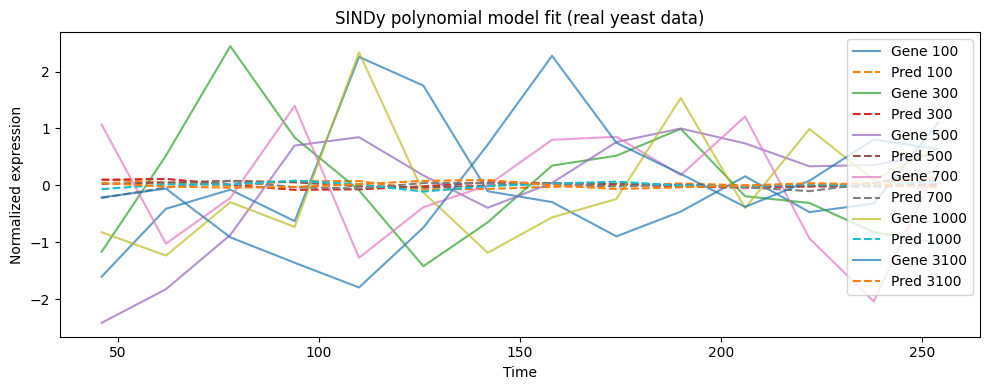

In [64]:
# --------------------------------------------
# Step 5: Predict and visualize reconstruction
# --------------------------------------------
import matplotlib.pyplot as plt

X_pred = model.predict(X_sparse)

plt.figure(figsize=(10, 4))
for i in range(X_sparse.shape[1]):
    plt.plot(time_ds, X_sparse[:, i], label=f"Gene {sensor_indices[i]}", alpha=0.7)
    plt.plot(time_ds, X_pred[:, i], '--', label=f"Pred {sensor_indices[i]}")
plt.title("SINDy polynomial model fit (real yeast data)")
plt.xlabel("Time")
plt.ylabel("Normalized expression")
plt.legend()
plt.tight_layout()
plt.show()


=== Combined Library (Polynomial + Hill) ===
(x0)' = 0.112 x0 + -0.035 x1 + -0.042 x2 + -0.001 x0^2 + 0.001 x0 x1
(x1)' = -448.048 1 + 0.092 x0 + -0.393 x1 + -0.910 x2 + -0.001 x0 x1 + 0.001 x1^2 + 0.004 x1 x2 + 0.004 x2^2 + 243.800 hill(x0) + 45.250 hill(x1) + 217.576 hill(x2)
(x2)' = -0.023 x0 + 0.034 x1 + -0.005 x2


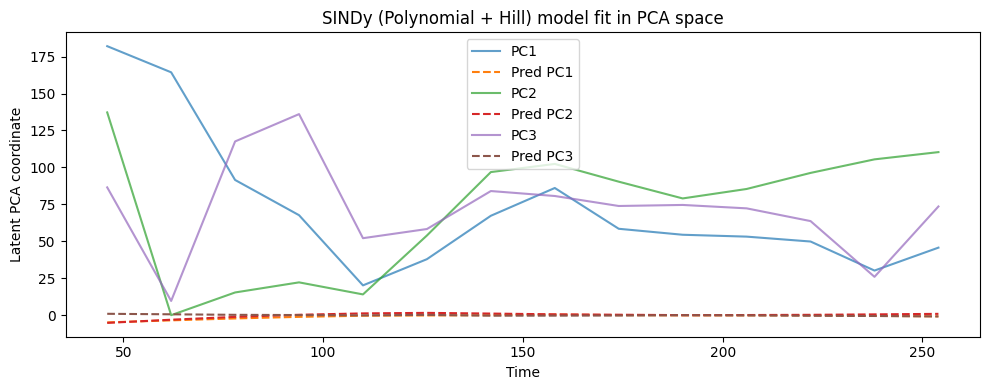

In [72]:
from pysindy.feature_library import CustomLibrary, PolynomialLibrary, GeneralizedLibrary
from pysindy.differentiation import SmoothedFiniteDifference
from pysindy.optimizers import STLSQ
import matplotlib.pyplot as plt

# Hill function (simple saturation)
def hill(x):
    return x / (1 + x)

hill_lib = CustomLibrary(
    library_functions=[hill],
    function_names=[lambda x: f"hill({x})"]
)

# Combined library: polynomial + hill
combined_library = GeneralizedLibrary([
    PolynomialLibrary(degree=3),
    hill_lib
])

model_combined = ps.SINDy(
    optimizer=STLSQ(threshold=0.0001),
    feature_library=combined_library,
    differentiation_method=SmoothedFiniteDifference()
)

Z_nonneg = Z - Z.min() + 1e-6

model_combined.fit(Z_nonneg, t=dt)
print("=== Combined Library (Polynomial + Hill) ===")
model_combined.print()

# Prediction and visualization
Z_nonneg_pred_combined = model_combined.predict(Z_nonneg)

plt.figure(figsize=(10, 4))
for i in range(Z_nonneg.shape[1]):
    plt.plot(time, Z_nonneg[:, i], label=f"PC{i+1}", alpha=0.7)
    plt.plot(time, Z_nonneg_pred_combined[:, i], '--', label=f"Pred PC{i+1}")
plt.title("SINDy (Polynomial + Hill) model fit in PCA space")
plt.xlabel("Time")
plt.ylabel("Latent PCA coordinate")
plt.legend()
plt.tight_layout()
plt.show()


=== Hill-Only Library ===
(x0)' = 0.003 hill(x0) + 0.002 hill(x1) + 0.006 hill(x2) + 0.002 hill(x3) + -0.005 hill(x4) + -0.005 hill(x5)
(x1)' = -0.001 hill(x1) + 0.006 hill(x2) + 0.001 hill(x3) + -0.005 hill(x4) + -0.004 hill(x5)
(x2)' = 0.005 hill(x2) + 0.002 hill(x3) + -0.005 hill(x4) + -0.006 hill(x5)
(x3)' = -0.006 hill(x2) + 0.002 hill(x4) + 0.004 hill(x5)
(x4)' = 0.007 hill(x2) + -0.005 hill(x5)
(x5)' = -0.001 hill(x0) + -0.013 hill(x2) + -0.001 hill(x3) + 0.005 hill(x4) + 0.009 hill(x5)


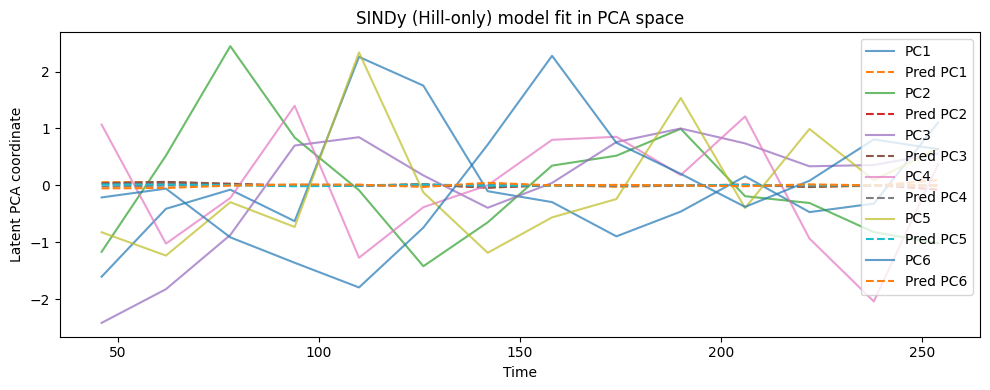

In [66]:
# Hill-only library
hill_only_library = CustomLibrary(
    library_functions=[hill],
    function_names=[lambda x: f"hill({x})"]
)

model_hill = ps.SINDy(
    optimizer=STLSQ(threshold=0.001),
    feature_library=hill_only_library,
    differentiation_method=SmoothedFiniteDifference()
)

model_hill.fit(X_sparse, t=dt)
print("=== Hill-Only Library ===")
model_hill.print()

# Prediction and visualization
X_sparse_pred_hill = model_hill.predict(X_sparse)

plt.figure(figsize=(10, 4))
for i in range(X_sparse.shape[1]):
    plt.plot(time, X_sparse[:, i], label=f"PC{i+1}", alpha=0.7)
    plt.plot(time, X_sparse_pred_hill[:, i], '--', label=f"Pred PC{i+1}")
plt.title("SINDy (Hill-only) model fit in PCA space")
plt.xlabel("Time")
plt.ylabel("Latent PCA coordinate")
plt.legend()
plt.tight_layout()
plt.show()


In [77]:
import pandas as pd
import numpy as np
import json

def load_synthetic_grn(tsv_path, json_path):
    # Load time series, skipping comment lines
    df = pd.read_csv(tsv_path, sep='\t', comment='#')
    
    t = df['time'].values
    X = df.drop(columns=['time']).values  # shape (T, G)
    gene_names = df.columns[1:].tolist()

    # Load metadata and parameters
    with open(json_path, 'r') as f:
        meta = json.load(f)

    print(f"✔ Loaded synthetic GRN: {tsv_path}")
    print(f"Timepoints: {len(t)} | Genes: {gene_names}")
    print(f"X shape: {X.shape}")
    print(f"Network topology:\n{meta['Network'].strip()}")

    return t, X, gene_names, meta


In [104]:
t, X, gene_names, params = load_synthetic_grn(
    "../yeast_data/syn_net/creation_of_datasets_6D/syn_net_6D_20191104_initial_data_run/syn_net_6D_20191104_a_data_p1048.tsv",
    "../yeast_data/syn_net/creation_of_datasets_6D/syn_net_6D_20191104_initial_data_run/syn_net_6D_20191104_a_hillmodel_p1048.json"
)

from sklearn.preprocessing import StandardScaler
from pysindy import SINDy
from pysindy.feature_library import PolynomialLibrary, CustomLibrary
from pysindy.differentiation import SmoothedFiniteDifference
from pysindy.optimizers import STLSQ
import matplotlib.pyplot as plt

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define Hill function
def hill(x): return x / (1 + x)
hill_lib = CustomLibrary(
    library_functions=[hill],
    function_names=[lambda x: f"hill({x})"]
)

# Fit combined model
model = SINDy(
    optimizer=STLSQ(threshold=0.01),
    feature_library=PolynomialLibrary(degree=3),  # or combine with hill_lib
    differentiation_method=SmoothedFiniteDifference()
)
model.fit(X_scaled, t=t)
model.print()


✔ Loaded synthetic GRN: ../yeast_data/syn_net/creation_of_datasets_6D/syn_net_6D_20191104_initial_data_run/syn_net_6D_20191104_a_data_p1048.tsv
Timepoints: 31 | Genes: ['A', 'B', 'C', 'D', 'E', 'F']
X shape: (31, 6)
Network topology:
A : (F) : E
B : (C) : E
C : (A + E)(~D) : E
D : (~A)(~E) : E
E : (F)(~B) : E
F : (~B) : E
(x0)' = 7382.027 1 + -4063.430 x0 + 2434.404 x1 + 4753.321 x2 + -4877.701 x3 + -1118.492 x4 + -4861.022 x5 + -666.133 x0^2 + -69.786 x0 x1 + -7031.644 x0 x2 + -154.258 x0 x3 + 1479.202 x0 x4 + -3036.213 x0 x5 + 2964.373 x1^2 + 2033.070 x1 x2 + 2792.181 x1 x4 + -4006.800 x2^2 + -618.623 x2 x4 + 3320.804 x2 x5 + -1272.360 x3^2 + -6000.558 x3 x4 + -5281.572 x3 x5 + -112.394 x4^2 + -7942.017 x5^2 + -2362.917 x0^3 + -5023.120 x0^2 x1 + 1999.431 x0^2 x2 + 895.910 x0^2 x3 + 1782.850 x0^2 x4 + 4487.208 x0^2 x5 + -4720.791 x0 x1^2 + -313.639 x0 x1 x2 + 1857.283 x0 x1 x3 + -9772.790 x0 x2^2 + 1061.065 x0 x2 x3 + 10581.367 x0 x2 x4 + -7119.946 x0 x2 x5 + 562.252 x0 x3^2 + -2224.

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pysindy as ps

thres = 1e-3

# Normalize to [0, 1] range for saturation-based functions
X_scaled = MinMaxScaler().fit_transform(X)

# Define biologically meaningful functions
def hill(x): return x / (1 + x)
def hill2(x): return x**2 / (1 + x**2)
def hill5(x): return x**5 / (1 + x**5)
def repress(x): return 1 / (1 + x)
def repress2(x): return 1 / (1 + x**2)
def activation(x): return x**2 / (1 + x**2)
def sigmoid(x): return 1 / (1 + np.exp(-x))

# Feature libraries
poly_lib = ps.PolynomialLibrary(degree=3)

bio_lib = ps.CustomLibrary(
    library_functions=[hill, hill2, hill5, repress, repress2, activation, sigmoid],
    function_names=[
        lambda x: f"hill({x})",
        lambda x: f"hill²({x})",
        lambda x: f"hill⁵({x})",
        lambda x: f"repress({x})",
        lambda x: f"repress²({x})",
        lambda x: f"activation({x})",
        lambda x: f"sigmoid({x})"
    ]
)

combo_lib = ps.GeneralizedLibrary([poly_lib, bio_lib])

# Define models
models = {
    "Polynomial Only": ps.SINDy(optimizer=ps.STLSQ(threshold=thres),
                                feature_library=poly_lib,
                                differentiation_method=ps.SmoothedFiniteDifference()),

    "Biological Only": ps.SINDy(optimizer=ps.STLSQ(threshold=thres),
                                feature_library=bio_lib,
                                differentiation_method=ps.SmoothedFiniteDifference()),

    "Polynomial + Biological": ps.SINDy(optimizer=ps.STLSQ(threshold=thres),
                                        feature_library=combo_lib,
                                        differentiation_method=ps.SmoothedFiniteDifference())
}

# Fit and evaluate
results = {}
for name, model in models.items():
    model.fit(X_scaled, t=t)
    coeffs = model.coefficients()
    X_pred = model.predict(X_scaled)
    residuals = X_scaled - X_pred
    sparsity = np.count_nonzero(coeffs) / coeffs.size
    mse = np.mean(residuals ** 2)

    results[name] = {
        "model": model,
        "coeffs": coeffs,
        "sparsity": sparsity,
        "mse": mse,
        "X_pred": X_pred,
        "residuals": residuals
    }

# Summary table
summary_df = pd.DataFrame({
    "Sparsity (%)": {k: 100 * v["sparsity"] for k, v in results.items()},
    "MSE": {k: v["mse"] for k, v in results.items()}
})
display(summary_df)


,Sparsity (%),MSE
Polynomial Only,98.214286,0.4032774522714476
Biological Only,98.412698,0.3986022606522866
Polynomial + Biological,97.089947,0.40327745227087247


In [ ]:
def plot_predictions(results, t, X_scaled, gene_names, n_dims=3):
    fig, axes = plt.subplots(len(results), 1, figsize=(12, 4 * len(results)), sharex=True)

    if len(results) == 1:
        axes = [axes]  # handle single model case

    for ax, (name, result) in zip(axes, results.items()):
        for i in range(min(n_dims, X_scaled.shape[1])):
            ax.plot(t, X_scaled[:, i], label=f'{gene_names[i]} true', alpha=0.5)
            ax.plot(t, result["X_pred"][:, i], '--', label=f'{gene_names[i]} pred', alpha=0.8)
        ax.set_title(f"{name} | Sparsity: {result['sparsity']:.2f} | MSE: {result['mse']:.4f}")
        ax.set_ylabel("Expression (normalized)")
        ax.legend(loc="upper right", fontsize=8)

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

def plot_residuals(results, t):
    fig, axes = plt.subplots(len(results), 1, figsize=(12, 3.5 * len(results)), sharex=True)

    if len(results) == 1:
        axes = [axes]

    for ax, (name, result) in zip(axes, results.items()):
        mse_t = np.mean(result["residuals"]**2, axis=1)
        ax.plot(t, mse_t, label="Mean squared residual")
        ax.set_title(f"{name} Residuals Over Time")
        ax.set_ylabel("MSE per timepoint")
        ax.grid(True)
        ax.legend()

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

def plot_coeff_heatmaps(results):
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))

    if len(results) == 1:
        axes = [axes]

    for ax, (name, result) in zip(axes, results.items()):
        im = ax.imshow(result["coeffs"], cmap="bwr", aspect="auto", interpolation="none")
        ax.set_title(f"{name} Coefficients")
        ax.set_xlabel("Library Terms")
        ax.set_ylabel("Gene Derivatives")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


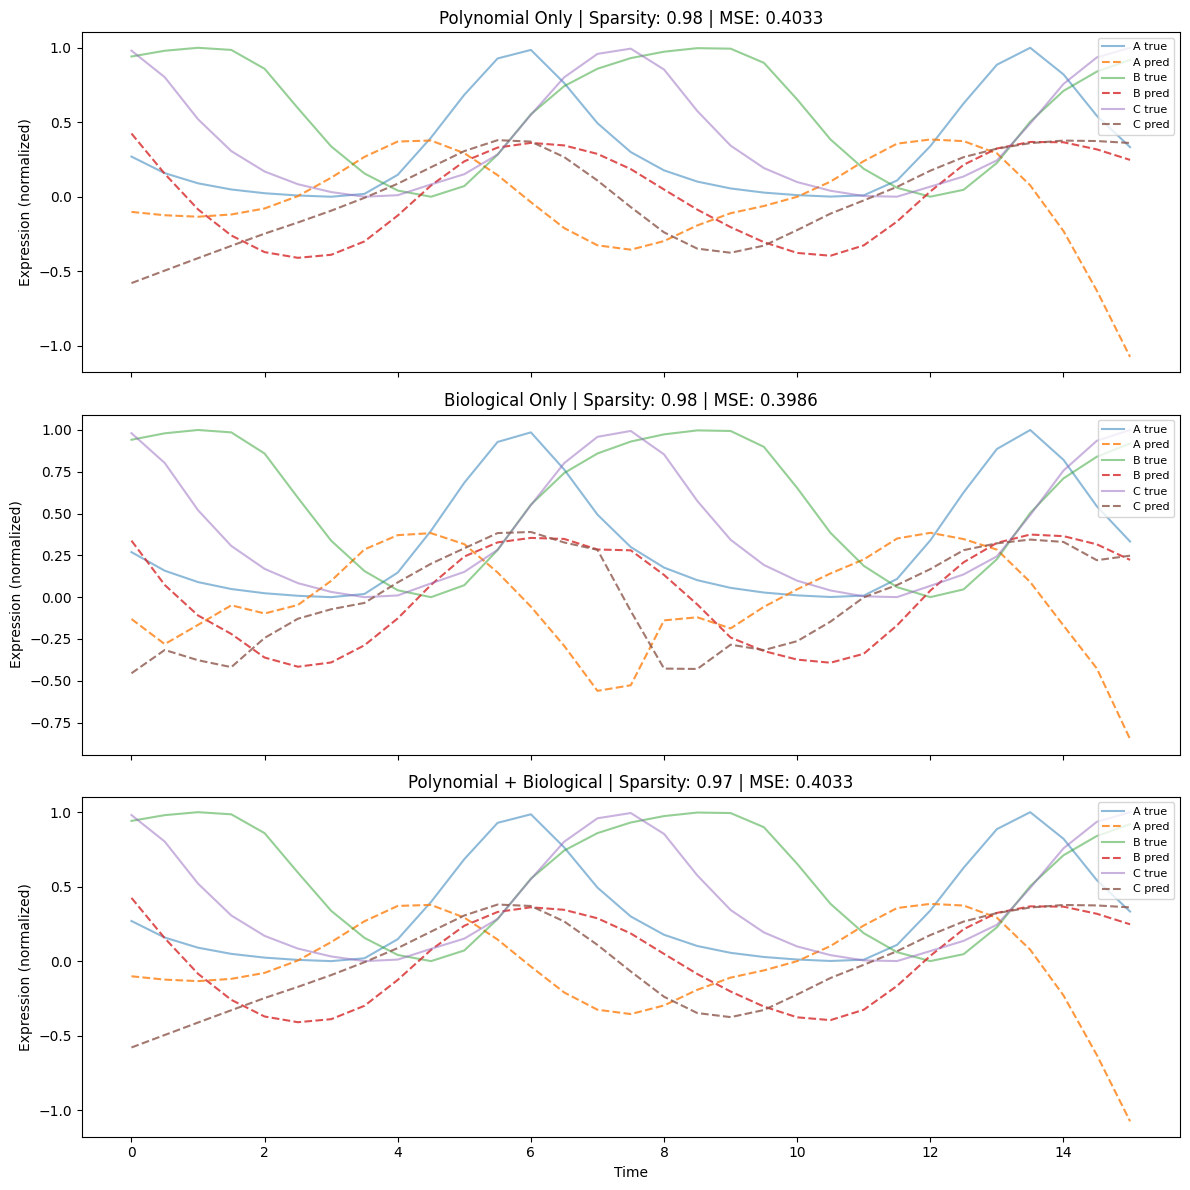

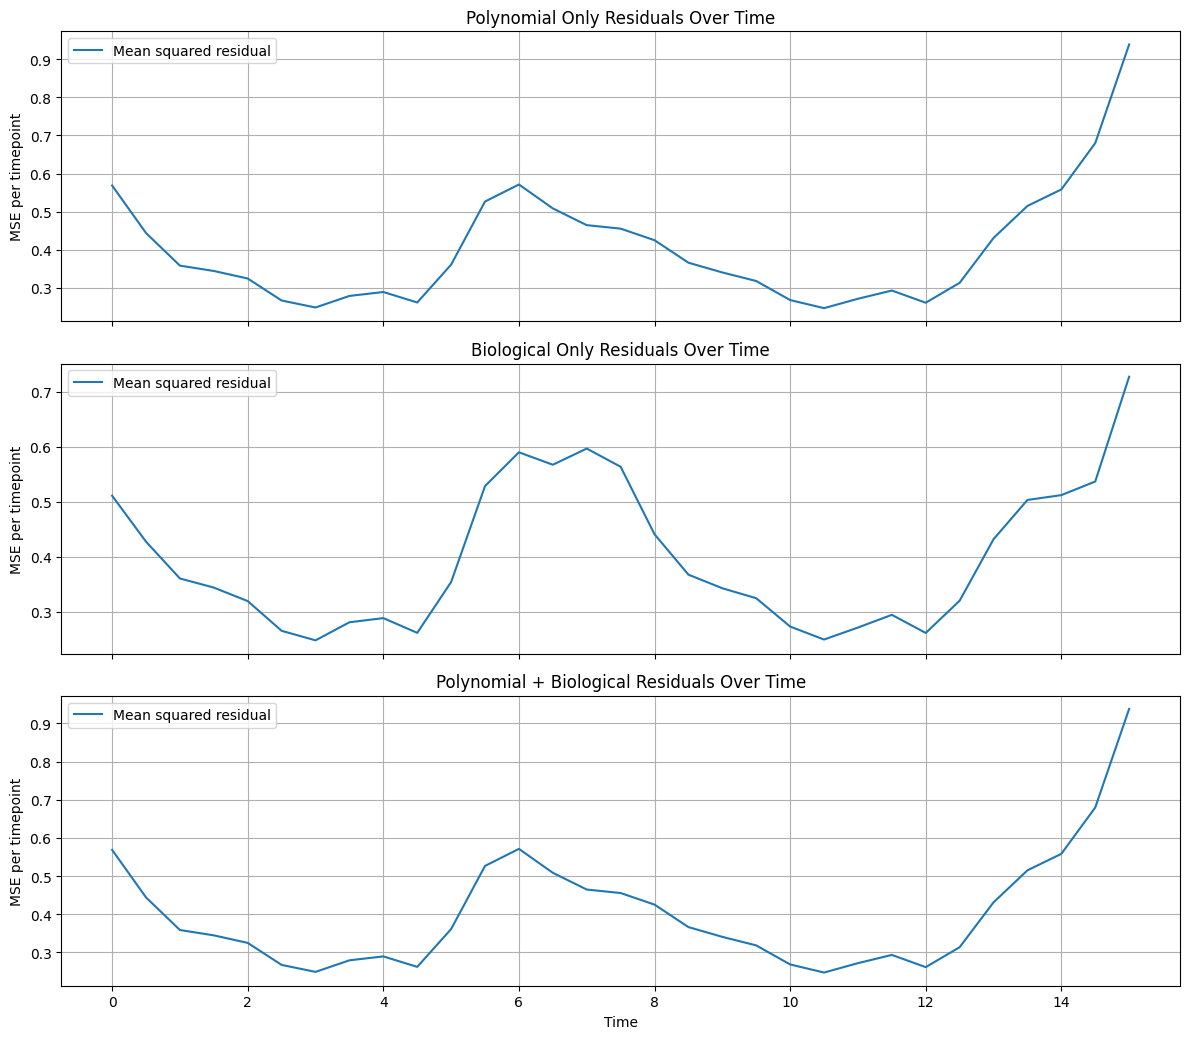

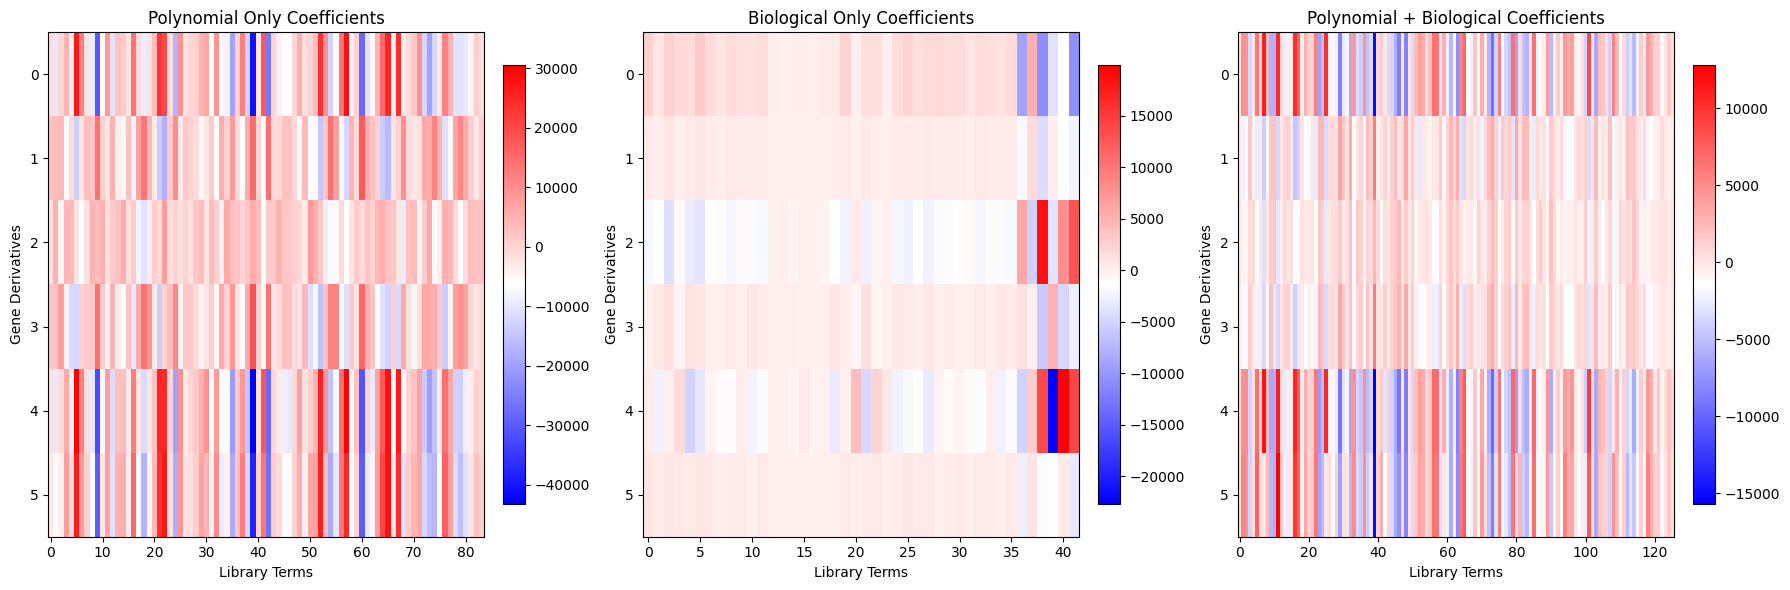

In [116]:
plot_predictions(results, t, X_scaled, gene_names, n_dims=3)
plot_residuals(results, t)
plot_coeff_heatmaps(results)


In [118]:
import os
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import MinMaxScaler
import pysindy as ps
from glob import glob

thres = 1e-3

# === Biological functions ===
def hill(x): return x / (1 + x)
def hill2(x): return x**2 / (1 + x**2)
def hill5(x): return x**5 / (1 + x**5)
def repress(x): return 1 / (1 + x)
def repress2(x): return 1 / (1 + x**2)
def activation(x): return x**2 / (1 + x**2)
def sigmoid(x): return 1 / (1 + np.exp(-x))

# === Libraries ===
poly_lib = ps.PolynomialLibrary(degree=3)
bio_lib = ps.CustomLibrary(
    library_functions=[hill, hill2, hill5, repress, repress2, activation, sigmoid],
    function_names=[
        lambda x: f"hill({x})", lambda x: f"hill²({x})", lambda x: f"hill⁵({x})",
        lambda x: f"repress({x})", lambda x: f"repress²({x})",
        lambda x: f"activation({x})", lambda x: f"sigmoid({x})"
    ]
)
combo_lib = ps.GeneralizedLibrary([poly_lib, bio_lib])

model_defs = {
    "Polynomial Only": poly_lib,
    "Biological Only": bio_lib,
    "Polynomial + Biological": combo_lib
}

# === Load paths ===
base_path = "../yeast_data/syn_net/creation_of_datasets_6D/syn_net_6D_20191104_initial_data_run"
tsv_files = sorted(glob(os.path.join(base_path, "*_data_p*.tsv")))[:10]

# === Batch run ===
all_results = []

for tsv_path in tsv_files:
    param_id = os.path.basename(tsv_path).split("_p")[-1].split(".")[0]
    json_path = tsv_path.replace("_data_", "_hillmodel_").replace(".tsv", ".json")

    # Load time series and metadata
    df = pd.read_csv(tsv_path, sep="\t", comment="#")
    t = df["time"].values
    X = df.drop(columns=["time"]).values
    gene_names = df.columns[1:].tolist()
    X_scaled = MinMaxScaler().fit_transform(X)

    # Run each model
    for model_name, lib in model_defs.items():
        model = ps.SINDy(
            optimizer=ps.STLSQ(threshold=thres),
            feature_library=lib,
            differentiation_method=ps.SmoothedFiniteDifference()
        )
        model.fit(X_scaled, t=t)
        mse = np.mean((X_scaled - model.predict(X_scaled))**2)
        sparsity = np.count_nonzero(model.coefficients()) / model.coefficients().size
        all_results.append({
            "Parameter ID": param_id,
            "Model": model_name,
            "MSE": mse,
            "Sparsity (%)": sparsity * 100
        })

# === To DataFrame ===
results_df = pd.DataFrame(all_results)
display(results_df)


,Parameter ID,Model,MSE,Sparsity (%)
0,0,Polynomial Only,0.42850962459358916,94.444444
1,0,Biological Only,0.4268112394382036,99.603175
2,0,Polynomial + Biological,0.4285096245939795,96.428571
3,1,Polynomial Only,0.4159740936677559,95.634921
4,1,Biological Only,0.4145885460552702,97.619048
5,1,Polynomial + Biological,0.4159740936679223,93.915344
6,10,Polynomial Only,0.4259150004496793,97.420635
7,10,Biological Only,0.42295224120798547,99.603175
8,10,Polynomial + Biological,0.4259150004507717,96.825397
9,100,Polynomial Only,0.28186990183478816,96.428571


In [137]:
import os 
import sys
sys.path.append(os.path.abspath("../yeast_data/syn_net/creation_of_datasets_6D"))

import numpy as np
from hillmodel import hillmodel

def sample_random_params(varnames):
    param = {}
    for source in varnames:
        for target in varnames:
            if source == target:
                continue
            key = f"[{source}, {target}]"
            param[f"L{key}"] = np.random.uniform(0.01, 0.5)
            param[f"U{key}"] = np.random.uniform(1.0, 3.0)
            param[f"T{key}"] = np.random.uniform(0.01, 1.0)
    return param

def generate_hill_dataset(N, network_file, hill_exp=5, T=30, total_time=15):
    """
    Generate [N, T, D] synthetic trajectories using hillmodel
    Ensures output timepoints are consistent and well-shaped
    """
    dataset = []
    dt = total_time / (T - 1)
    timepoints = np.linspace(0, total_time, T)
    varnames = None

    for i in range(N):
        if varnames is None:
            dummy_params = sample_random_params(['A', 'B', 'C', 'D', 'E', 'F'])
            dummy_model = hillmodel(network_file, dummy_params, hill_exp)
            varnames = dummy_model.varnames

        params = sample_random_params(varnames)
        model = hillmodel(network_file, params, hill_exp)
        D = model.dim()
        y0 = np.random.uniform(0.1, 2.0, size=D)

        times, traces, _ = model.simulateHillModel(
            initialconditions=y0,
            initialtime=0,
            finaltime=total_time,
            timestep=dt
        )

        # Ensure length consistency
        traces = np.array(traces)
        if traces.shape[0] > T:
            traces = traces[:T]
        elif traces.shape[0] < T:
            pad = np.tile(traces[-1], (T - traces.shape[0], 1))
            traces = np.vstack([traces, pad])

        dataset.append(traces)

    dataset = np.stack(dataset)  # shape: (N, T, D)
    return dataset, timepoints, varnames


In [145]:
X_all, t, gene_names = generate_hill_dataset(
    N=100,
    network_file="../yeast_data/syn_net/creation_of_datasets_6D/syn_net_6D_20191104_a.txt",
    hill_exp=5,
    T=250,
    total_time=15
)

print(f"Shape: {X_all.shape}")  # → (100, 30, 6)


Shape: (100, 250, 6)


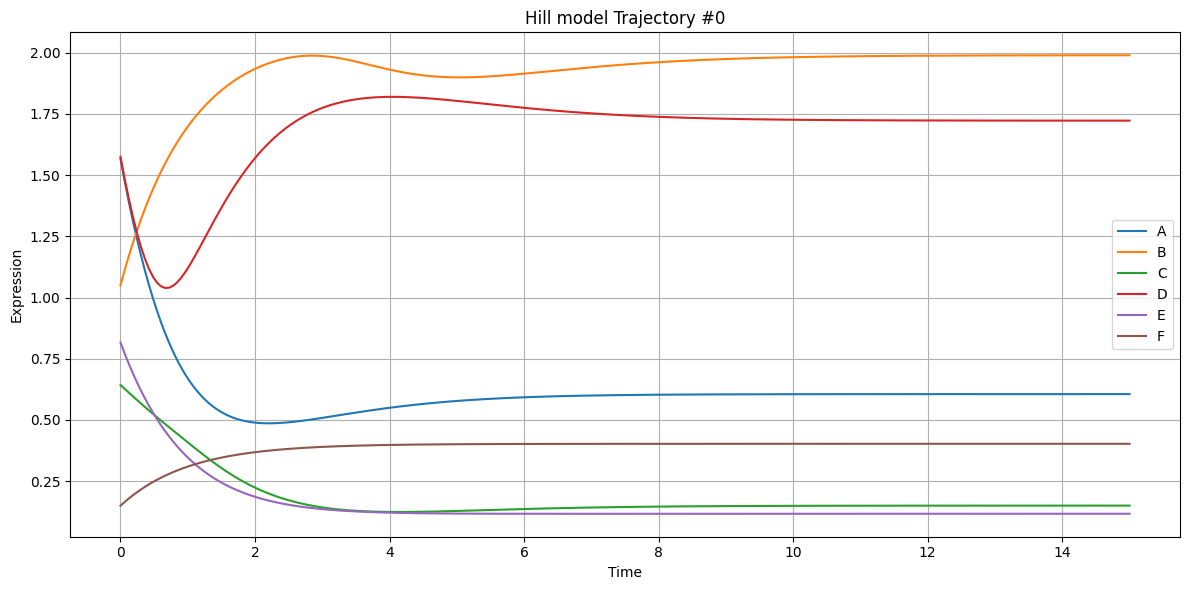

In [146]:
import matplotlib.pyplot as plt

# Choose a sample index and unpack
sample_idx = 0
trajectory = X_all[sample_idx]  # shape (250, 6)

plt.figure(figsize=(12, 6))
for i in range(trajectory.shape[1]):
    plt.plot(t, trajectory[:, i], label=f"{gene_names[i]}")
plt.xlabel("Time")
plt.ylabel("Expression")
plt.title(f"Hill model Trajectory #{sample_idx}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [147]:
import torch
from torch.utils.data import Dataset

class HillTrajectoryDataset(Dataset):
    def __init__(self, X, t, normalize=True):
        """
        X: numpy array of shape (N, T, D)
        t: numpy array of shape (T,)
        """
        self.X = X.astype(np.float32)
        self.t = torch.tensor(t, dtype=torch.float32)

        if normalize:
            self._normalize()

    def _normalize(self):
        # Min-max normalization per gene
        mins = self.X.min(axis=(0, 1), keepdims=True)
        maxs = self.X.max(axis=(0, 1), keepdims=True)
        self.X = (self.X - mins) / (maxs - mins + 1e-6)

    def __len__(self):
        return self.X.shape[0]  # number of trajectories

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)  # shape (T, D)
        return x, self.t  # return full time series and its time vector


In [161]:
from torch.utils.data import DataLoader

# Assume you’ve already generated data
X_all, t, gene_names = generate_hill_dataset(N=100, T=250, total_time=100,
    network_file="../yeast_data/syn_net/creation_of_datasets_6D/syn_net_6D_20191104_a.txt")

dataset = HillTrajectoryDataset(X_all, t)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Inspect one batch
for X_batch, t_batch in dataloader:
    print(X_batch.shape)  # (batch_size, T, D)
    print(t_batch.shape)  # (T,)
    break


torch.Size([16, 250, 6])
torch.Size([16, 250])


In [ ]:
import torch
import torch.nn as nn

class RNNEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=64, rnn_type="GRU"):
        super().__init__()
        rnn_cls = nn.GRU if rnn_type == "GRU" else nn.LSTM
        self.rnn = rnn_cls(input_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: [B, T, D]
        rnn_out, _ = self.rnn(x)  # [B, T, H]
        z = self.linear(rnn_out)  # [B, T, L]
        return z

class LinearDecoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(latent_dim, output_dim)

    def forward(self, z):
        return self.linear(z)  # [B, T, D]

from pysindy.optimizers import STLSQ
from pysindy.feature_library import PolynomialLibrary

class SINDyLayer(nn.Module):
    def __init__(self, latent_dim, poly_degree=3, threshold=0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.library = PolynomialLibrary(degree=poly_degree)
        self.optimizer = STLSQ(threshold=threshold)

    def fit(self, z, dzdt):
        self.library.fit(z)
        theta = self.library.transform(z)
        self.optimizer.fit(theta, dzdt)
        
        # Make sure the output is always (n_terms, latent_dim)
        coeffs = self.optimizer.coef_
        if coeffs.ndim == 1:
            coeffs = coeffs[:, np.newaxis]  # shape (n_terms, 1)
        self.coeffs = coeffs


    def predict(self, z):
        theta = self.library.transform(z)
        #print("Θ shape:", theta.shape) # debugging
        #print("Ξ shape:", self.coeffs.shape) # debugging

        return theta @ self.coeffs.T
    
    def print_equations(self, input_names=None, output_names=None):
        equations = self.library.get_feature_names(input_names)
        for i in range(self.coeffs.shape[1]):
            terms = []
            for coef, name in zip(self.coeffs[:, i], equations):
                if np.abs(coef) > 1e-6:
                    terms.append(f"{coef:+.3f}·{name}")
            rhs = " ".join(terms) if terms else "0"
            out_name = output_names[i] if output_names and i < len(output_names) else f"(z{i})"
            print(f"d{out_name}/dt = {rhs}")



class SINDySHRED(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=64, poly_degree=3, threshold=0.1):
        super().__init__()
        self.encoder = RNNEncoder(input_dim, latent_dim, hidden_dim)
        self.decoder = LinearDecoder(latent_dim, input_dim)
        self.sindy = SINDyLayer(latent_dim, poly_degree, threshold)

    def forward(self, x, dt: float):
        z = self.encoder(x)              # [B, T, L]
        x_hat = self.decoder(z)          # [B, T, D]

        # Estimate dz/dt via finite differences
        dzdt = (z[:, 1:, :] - z[:, :-1, :]) / dt      # [B, T-1, L]
        z_mid = (z[:, 1:, :] + z[:, :-1, :]) / 2      # midpoint samples

        # Flatten across time
        z_flat = z_mid.reshape(-1, z_mid.shape[-1])
        dzdt_flat = dzdt.reshape(-1, dzdt.shape[-1])

        self.sindy.fit(z_flat.detach().cpu().numpy(), dzdt_flat.detach().cpu().numpy())

        # symbolic prediction (for loss eval)
        dzdt_pred = self.sindy.predict(z_flat.detach().cpu().numpy())
        dzdt_pred = torch.tensor(dzdt_pred, dtype=z.dtype).to(x.device)
        dzdt_pred = dzdt_pred.reshape(dzdt.shape)

        return x_hat, dzdt, dzdt_pred

def shred_loss(x, x_hat, dzdt, dzdt_pred, alpha=1.0, beta=1.0):
    recon_loss = nn.functional.mse_loss(x_hat, x)
    dyn_loss = nn.functional.mse_loss(dzdt_pred, dzdt)
    return alpha * recon_loss + beta * dyn_loss

In [170]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model and move to device
model = SINDySHRED(input_dim=6, latent_dim=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Precompute dt once from your time vector (shape [T])
dt = (t[1] - t[0]).item()

# Training loop
for epoch in range(10):
    for X_batch, _ in dataloader:  # we ignore t_batch now
        X_batch = X_batch.to(device)

        x_hat, dzdt, dzdt_pred = model(X_batch, dt)
        loss = shred_loss(X_batch, x_hat, dzdt, dzdt_pred)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1} | Loss: {loss.item():.4f}")


Using device: cuda
Epoch 1 | Loss: 0.1111
Epoch 2 | Loss: 0.2172
Epoch 3 | Loss: 0.1162
Epoch 4 | Loss: 0.1151
Epoch 5 | Loss: 0.1176
Epoch 6 | Loss: 0.0576
Epoch 7 | Loss: 0.0311
Epoch 8 | Loss: 0.0272
Epoch 9 | Loss: 0.0222
Epoch 10 | Loss: 0.0214


In [172]:
latent_dim = model.encoder.linear.out_features  # or just 3
model.sindy.print_equations(
    input_names=[f"z{i}" for i in range(latent_dim)],
    output_names=[f"z{i}" for i in range(latent_dim)],
)


dz0/dt = +0.557·1 +0.391·z0 +0.446·z1
dz1/dt = +0.145·1 +0.375·z0 +0.278·z1
dz2/dt = +0.515·z0


IndexError: list index out of range